# Clusturing - Kumeleme

Clustering benzer nesnelerin veya verilerin gruplar halinde toplanmasi demektir.  
Bu projede araba benzerliklerine gore gruplara ayricagiz.

In [1]:
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel('cars.xls')

In [5]:
df.head()

,Price,Mileage,Make,Model,Trim,Type,Cylinder,Liter,Doors,Cruise,Sound,Leather
0,17314.103129,8221,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,1
1,17542.036083,9135,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
2,16218.847862,13196,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,1,0
3,16336.913140,16342,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,0
4,16339.170324,19832,Buick,Century,Sedan 4D,Sedan,6,3.1,4,1,0,1


In [6]:
x = df[['Price', 'Mileage', 'Cylinder']]

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [23]:
model = KMeans(4)

In [24]:
model= model.fit(x)

In [25]:
tahmin = model.predict(x)

In [26]:
x['cluster'] = tahmin

/var/folders/jz/r6ptw_ts6h9gb32_v0twwpm80000gn/T/ipykernel_902/2044112464.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x['cluster'] = tahmin


In [12]:
x.head()

,Price,Mileage,Cylinder,cluster
0,17314.103129,8221,6,2
1,17542.036083,9135,6,2
2,16218.847862,13196,6,2
3,16336.913140,16342,6,2
4,16339.170324,19832,6,0


<Axes: xlabel='cluster', ylabel='count'>

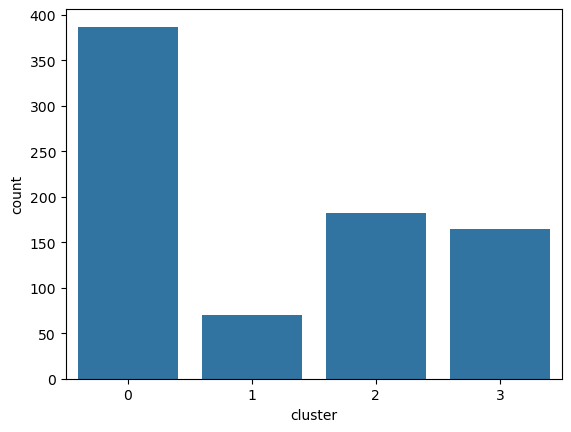

In [14]:
sns.countplot(x = x['cluster'])

In [ ]:
silhouette_score(x, tahmin) # 0.5'nin üzerinde olması iyi bir sonuçtur.

0.41303400960248826

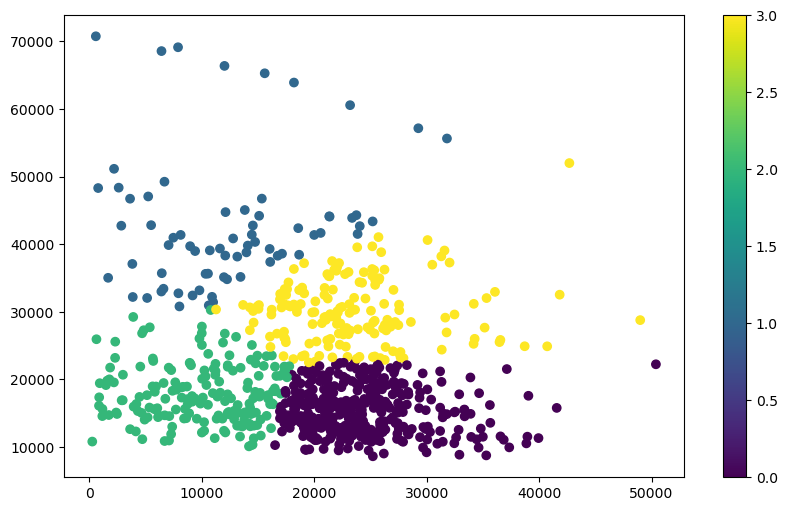

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(x.Mileage, x.Price, c=tahmin)
plt.colorbar()

In [21]:
#wcss= within cluster sum of squares
wcss=[]
ss=[]
for i in range(2,10):
    model=KMeans(i)
    model=model.fit(x)
    tahmin=model.predict(x)
    ss1=silhouette_score(x,tahmin)
    ss.append(ss1)
    print(ss1)
    wcss.append(model.inertia_)

0.4510408914930838
0.4148818584897196
0.4114527987213462
0.3550640631801172
0.33589407709405844
0.36191060568727795
0.36182289127875716
0.34509800020500425


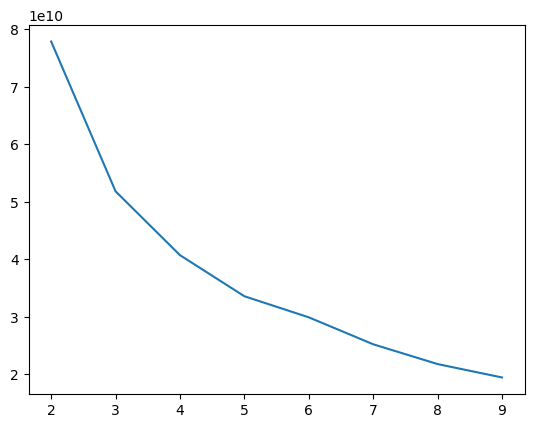

In [22]:
plt.plot(range(2,10),wcss)

In [ ]:
from yellowbrick.cluster import KElbowVisualizer

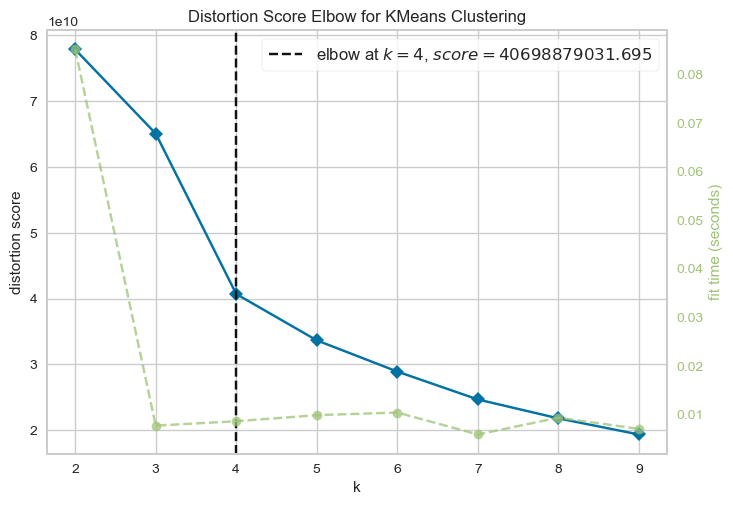

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [28]:
vis = KElbowVisualizer(KMeans(), k=(2,10))
vis.fit(x)
vis.show()

## Hierarchical Clustering

In [29]:
from scipy.cluster.hierarchy import dendrogram, linkage

In [30]:
data = linkage(x, method='ward', metric='euclidean')

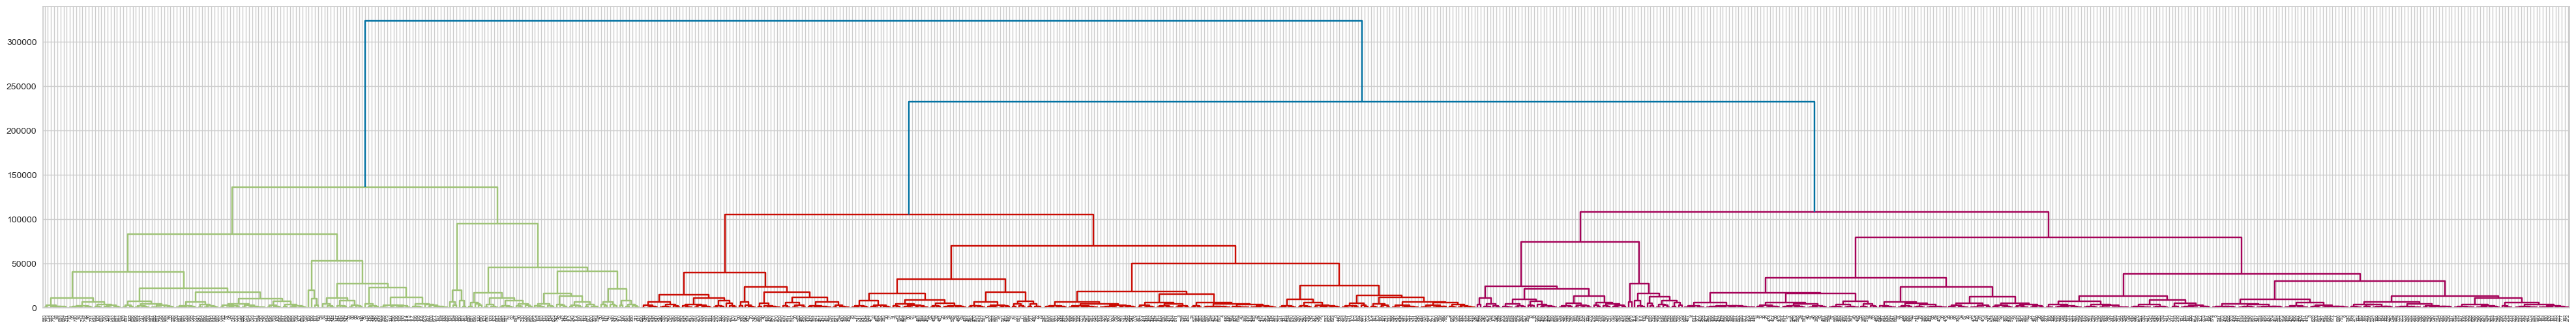

In [35]:
plt.figure(figsize=(50, 6))
dendrogram(data);

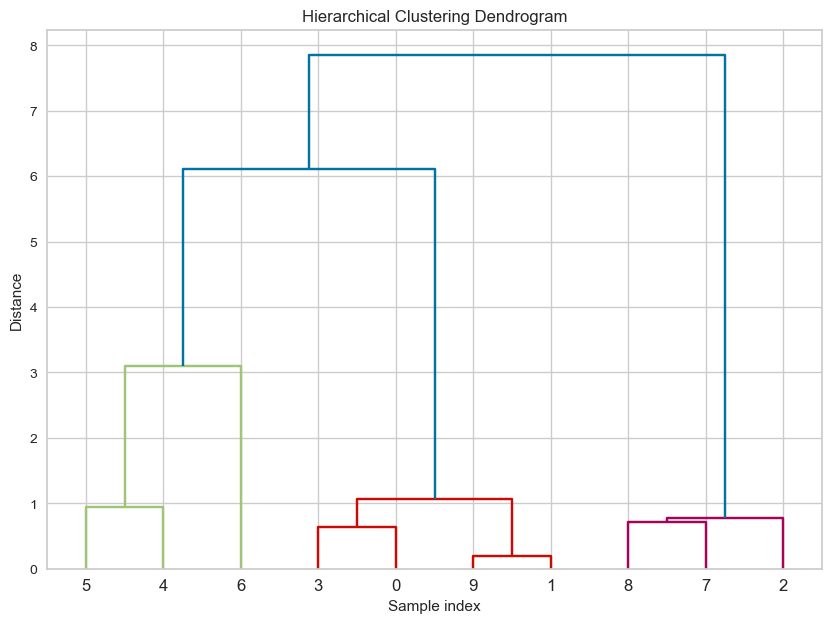

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.cluster.hierarchy import dendrogram, linkage

# Generate sample data
X, _ = make_blobs(n_samples=10, centers=3, cluster_std=0.60, random_state=0)

# Perform hierarchical clustering
linked = linkage(X, 'ward')

# Create a dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.show()

In [37]:
from sklearn.cluster import DBSCAN

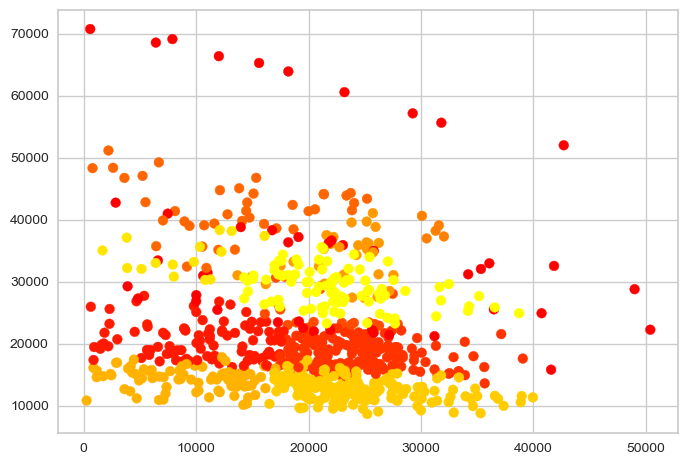

In [38]:
db=DBSCAN(min_samples=5)
from sklearn.preprocessing import StandardScaler
x2=StandardScaler().fit_transform(x)
y=db.fit_predict(x2)

plt.scatter(x['Mileage'],x['Price'],c=y,cmap='autumn');
plt.savefig('clustering.png', dpi=300)

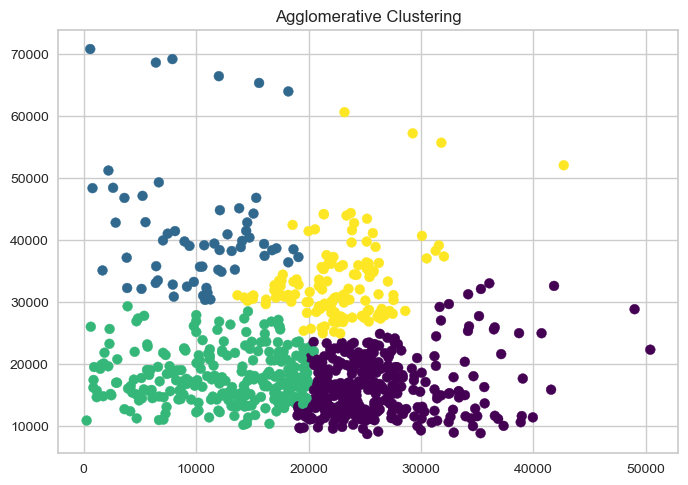

In [39]:
from sklearn.cluster import AgglomerativeClustering
agg_clustering = AgglomerativeClustering(n_clusters=4)
y_agg = agg_clustering.fit_predict(x)

# Plot the results
plt.scatter(x.Mileage, x.Price, c=y_agg, s=50, cmap='viridis')
plt.title("Agglomerative Clustering")
plt.show()

In [40]:
df = pd.read_csv('Billionaires.csv')

In [41]:
df.head()

,rank,finalWorth,category,personName,age,country,city,source,industries,countryOfCitizenship,...,cpi_change_country,gdp_country,gross_tertiary_education_enrollment,gross_primary_education_enrollment_country,life_expectancy_country,tax_revenue_country_country,total_tax_rate_country,population_country,latitude_country,longitude_country
0,1,211000,Fashion & Retail,Bernard Arnault & family,74.0,France,Paris,LVMH,Fashion & Retail,France,...,1.1,"$2,715,518,274,227",65.6,102.5,82.5,24.2,60.7,67059887.0,46.227638,2.213749
1,2,180000,Automotive,Elon Musk,51.0,United States,Austin,"Tesla, SpaceX",Automotive,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
2,3,114000,Technology,Jeff Bezos,59.0,United States,Medina,Amazon,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
3,4,107000,Technology,Larry Ellison,78.0,United States,Lanai,Oracle,Technology,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891
4,5,106000,Finance & Investments,Warren Buffett,92.0,United States,Omaha,Berkshire Hathaway,Finance & Investments,United States,...,7.5,"$21,427,700,000,000",88.2,101.8,78.5,9.6,36.6,328239523.0,37.090240,-95.712891


<Axes: xlabel='selfMade', ylabel='count'>

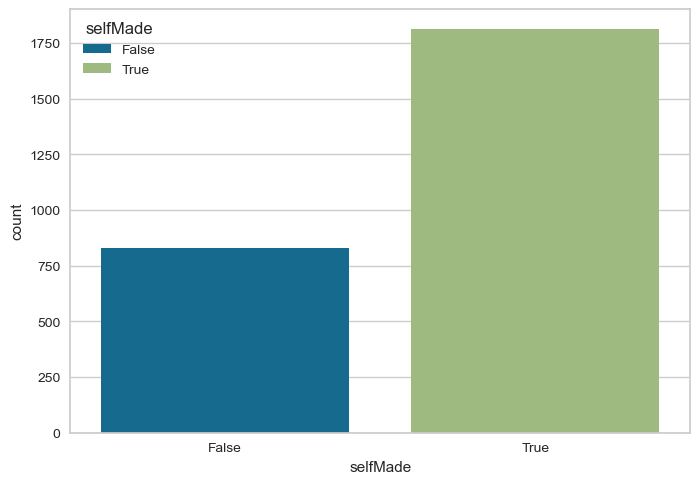

In [42]:
sns.countplot(x = df['selfMade'], hue=df['selfMade'])

<Axes: xlabel='count', ylabel='country'>

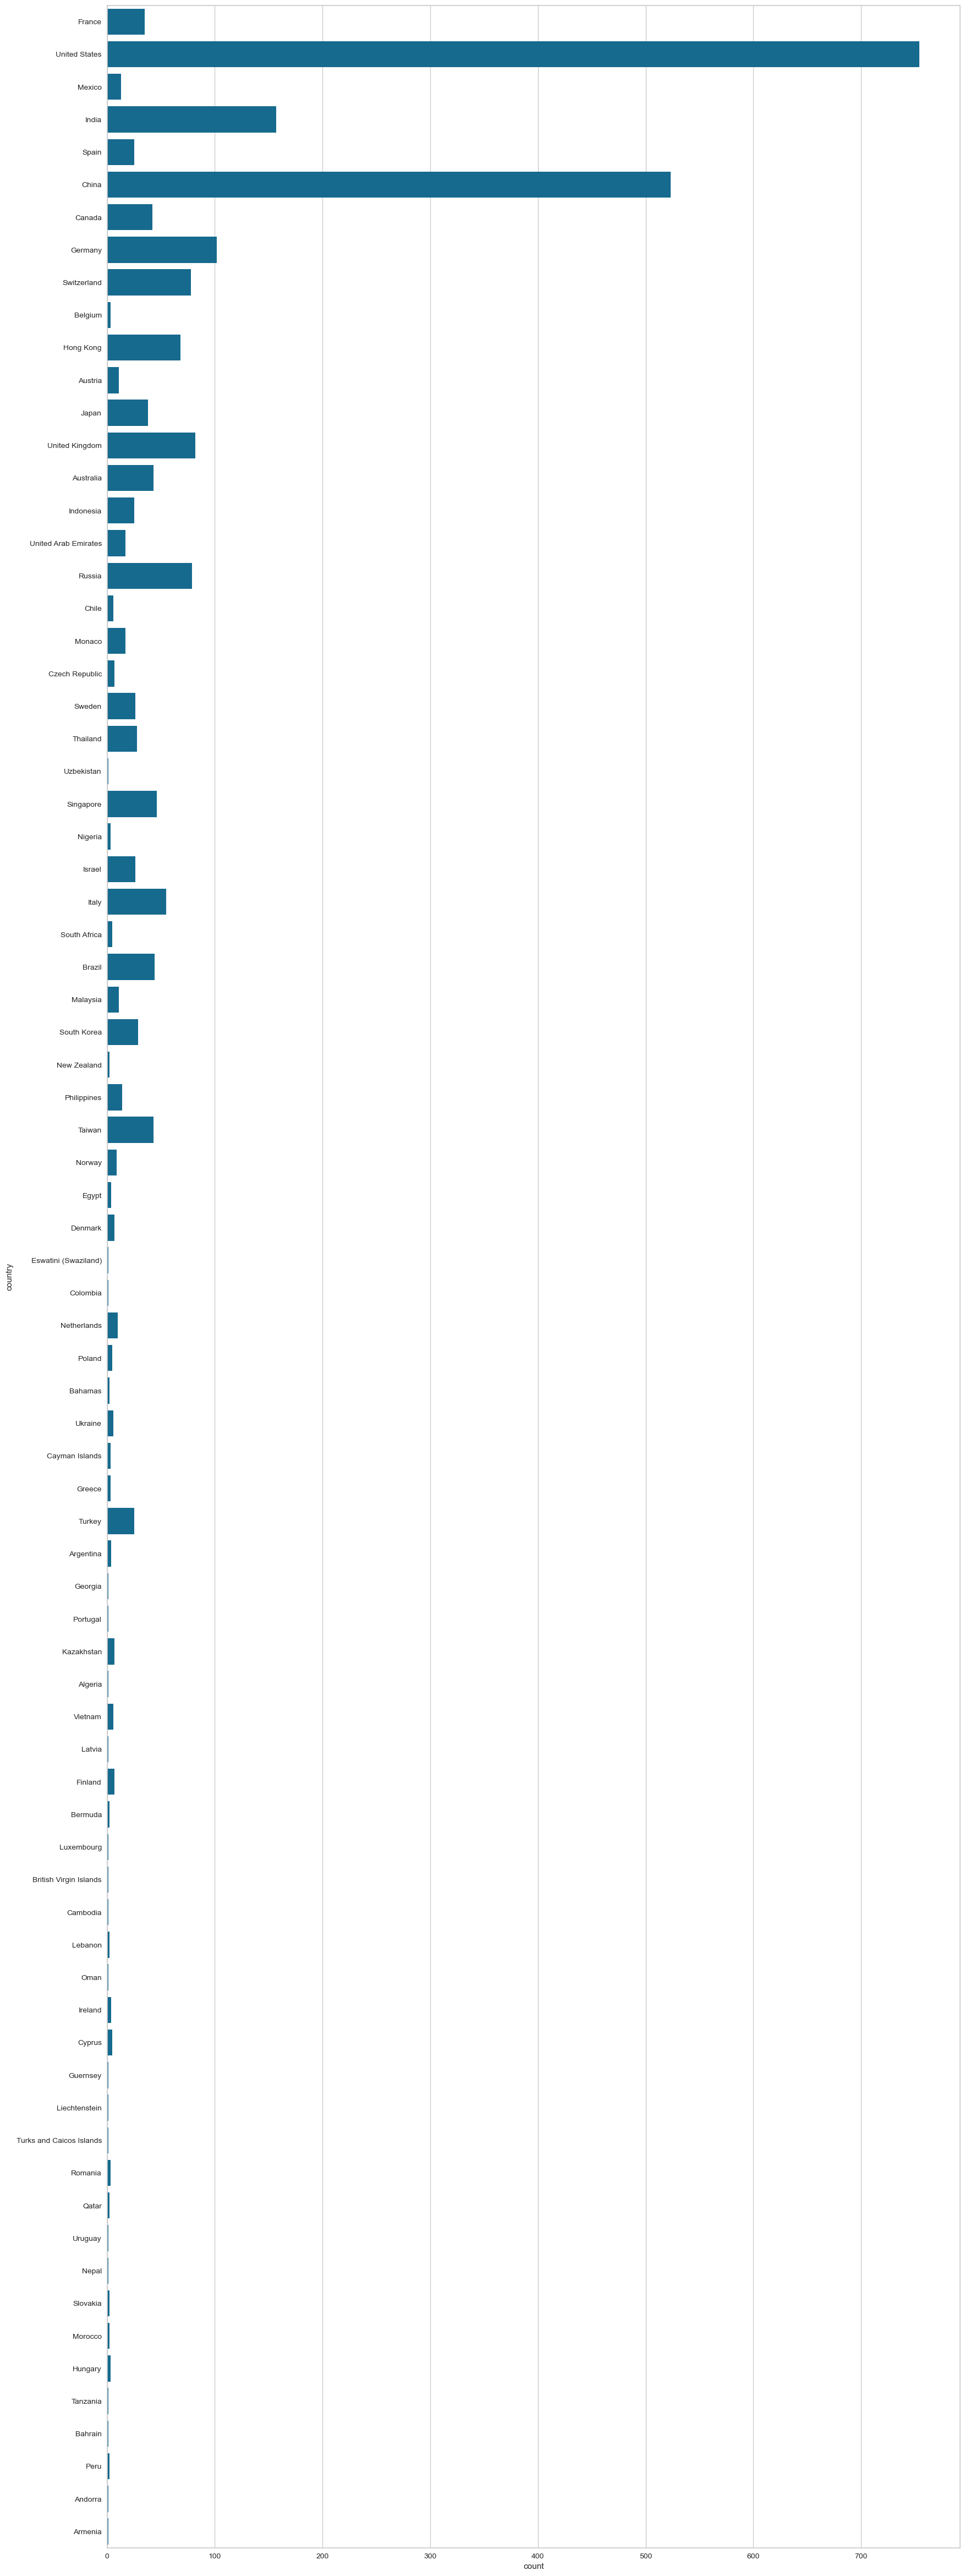

In [43]:
plt.figure(figsize=(20, 60))
sns.countplot(y = df['country'])

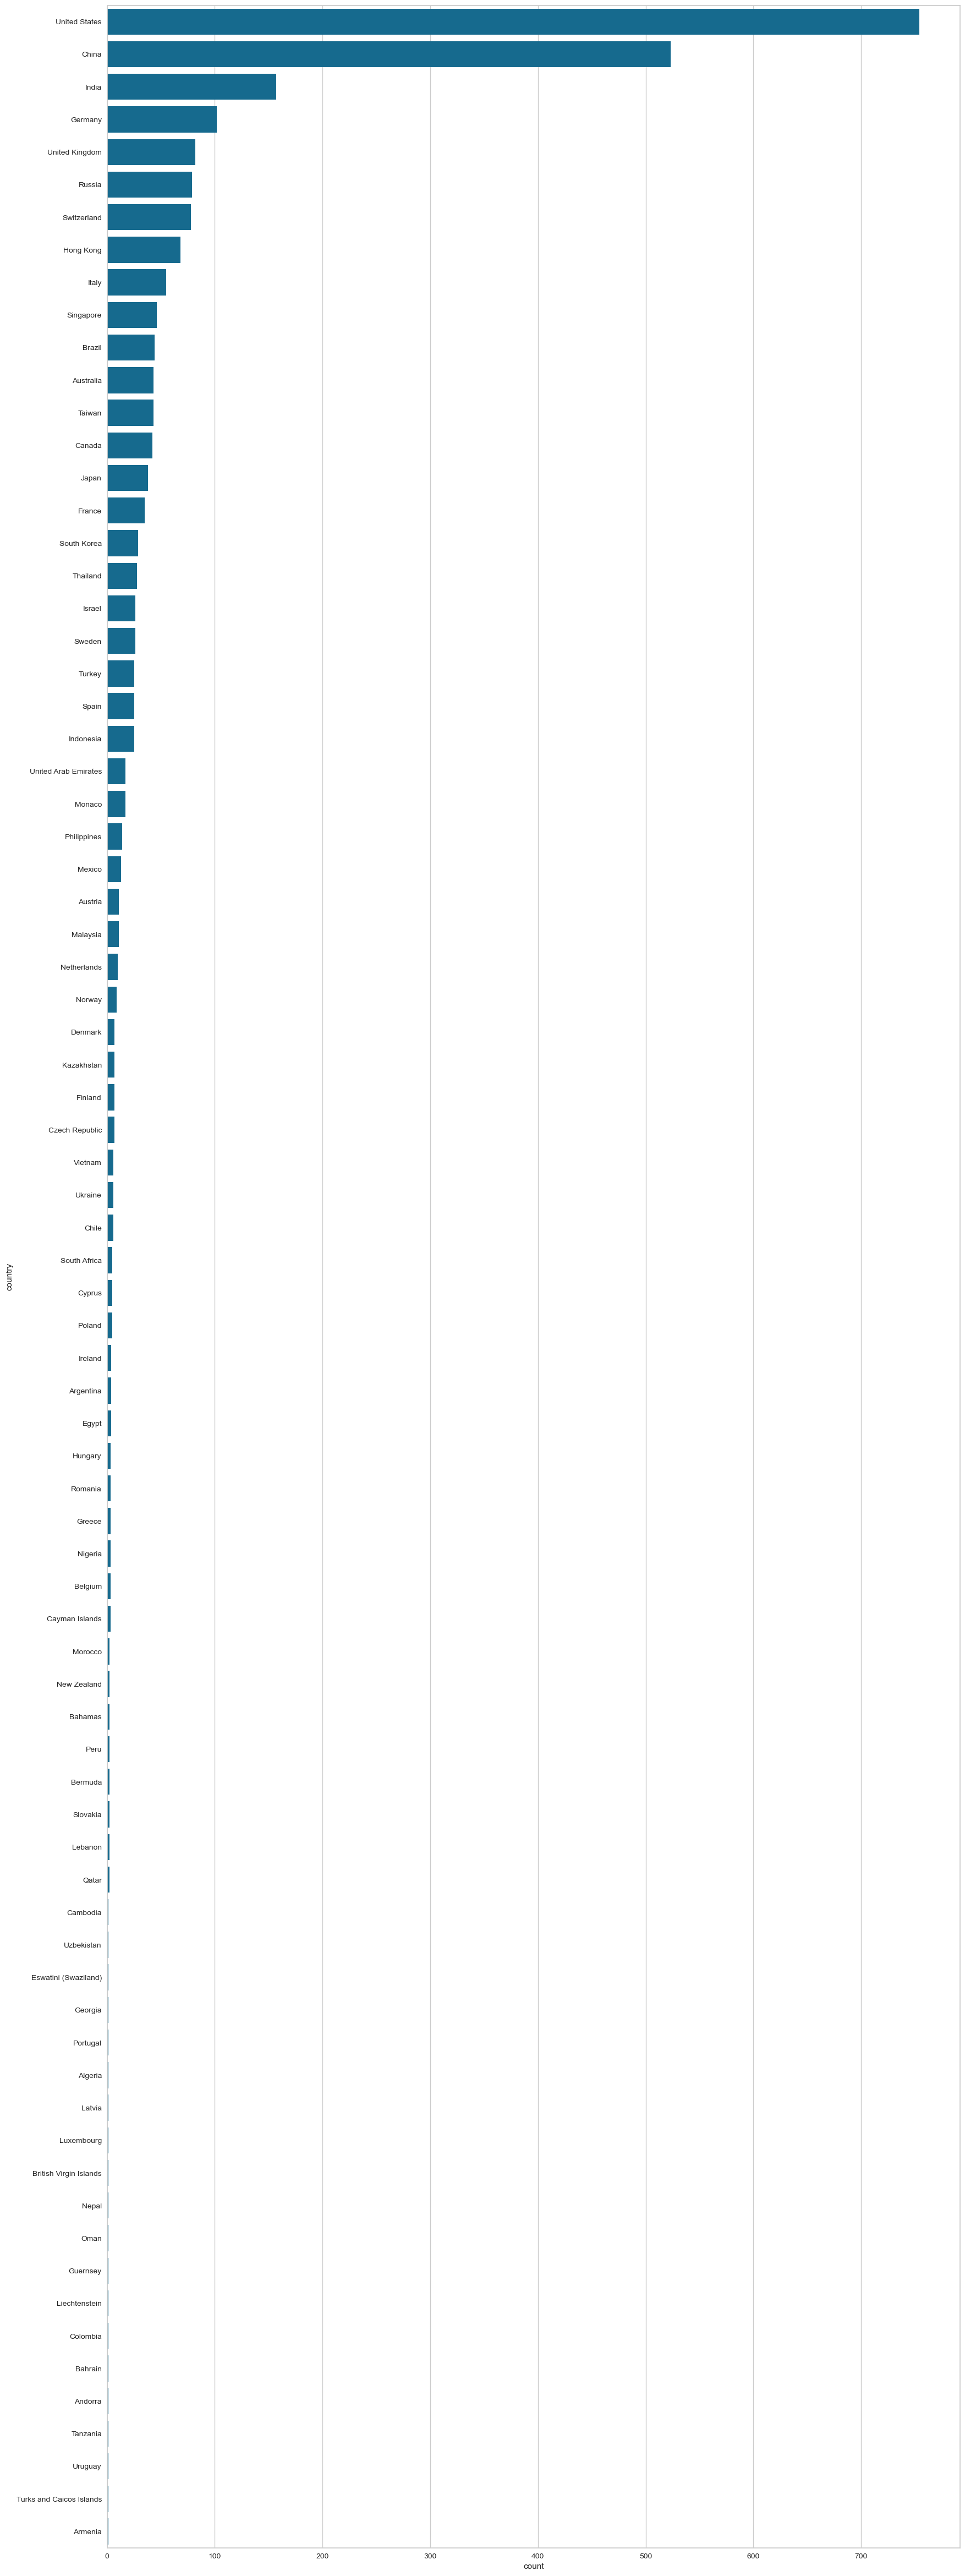

In [44]:
ydf=df['country'].value_counts().sort_values(ascending=False)
plt.figure(figsize=(20,60))
sns.countplot(y=df['country'],order=ydf.index);

In [45]:
tr=df[df['country']=='Turkey']

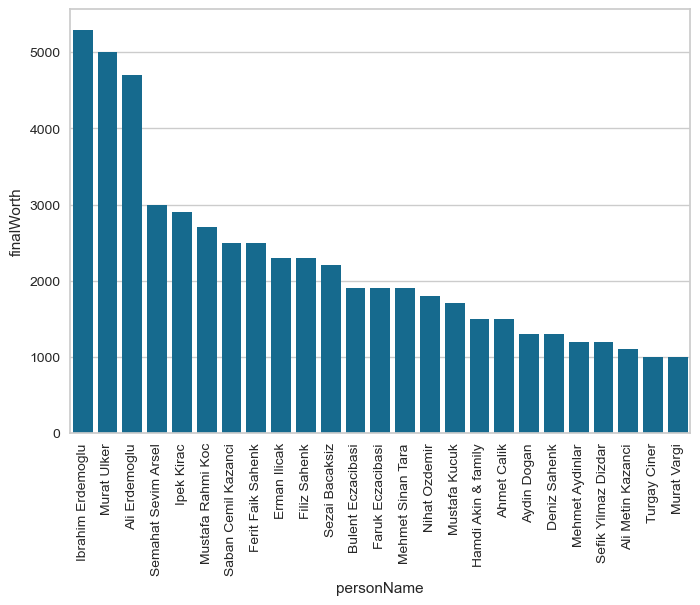

In [46]:
sns.barplot(x=tr['personName'],y=tr['finalWorth'])
plt.xticks(rotation=90);

<Axes: xlabel='selfMade', ylabel='count'>

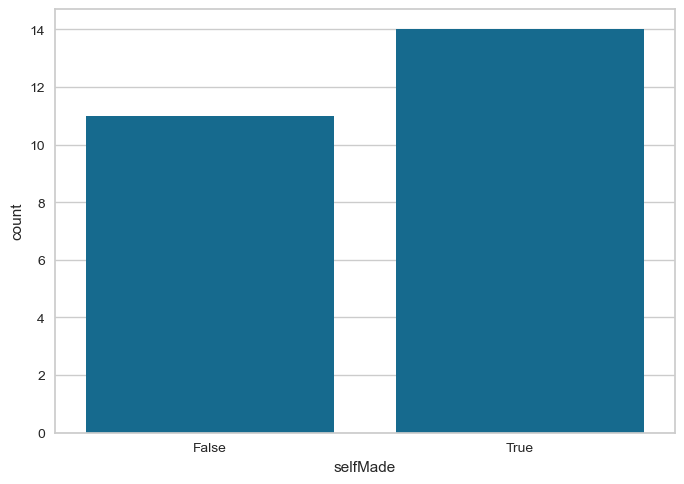

In [48]:
sns.countplot(x = tr['selfMade'])

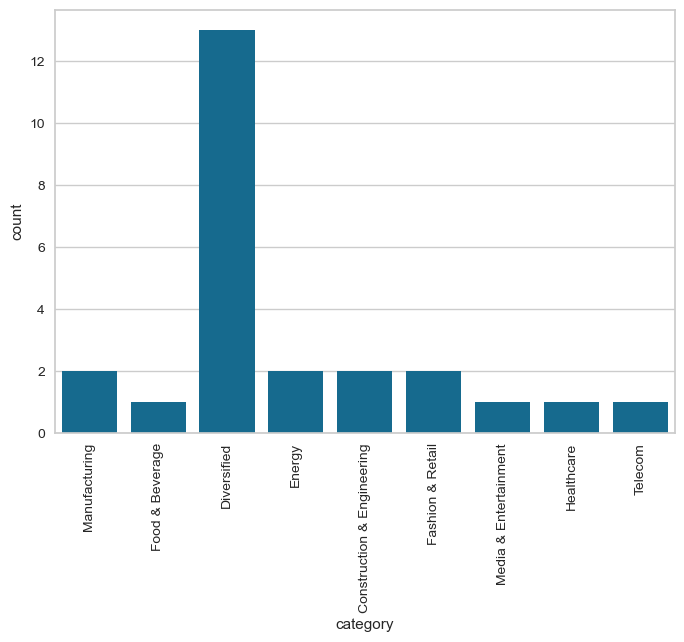

In [47]:
sns.countplot(x=tr['category'])
plt.xticks(rotation=90)
plt.show()

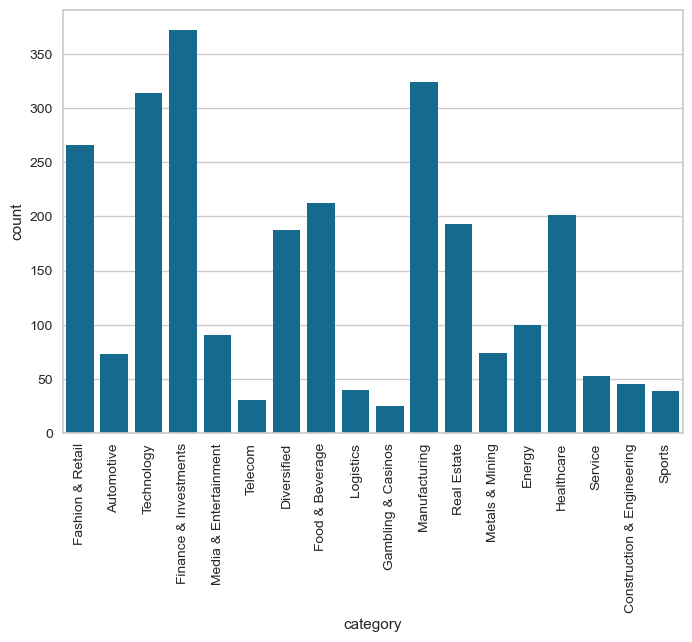

In [49]:
sns.countplot(x=df['category'])
plt.xticks(rotation=90)
plt.show()

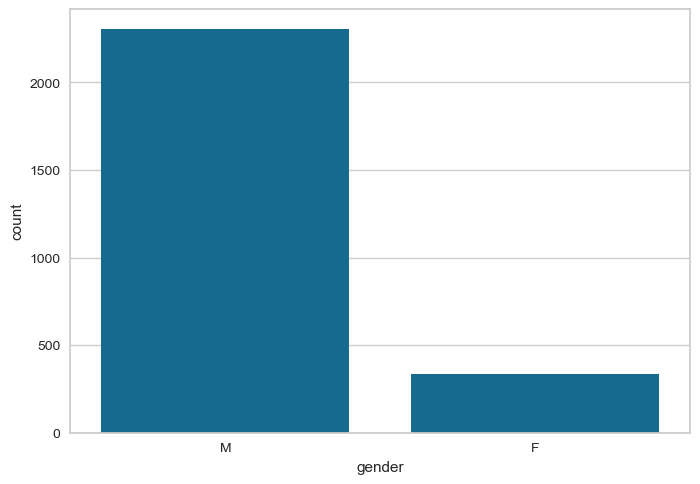

In [50]:
sns.countplot(x=df['gender']);

<Axes: xlabel='count', ylabel='country'>

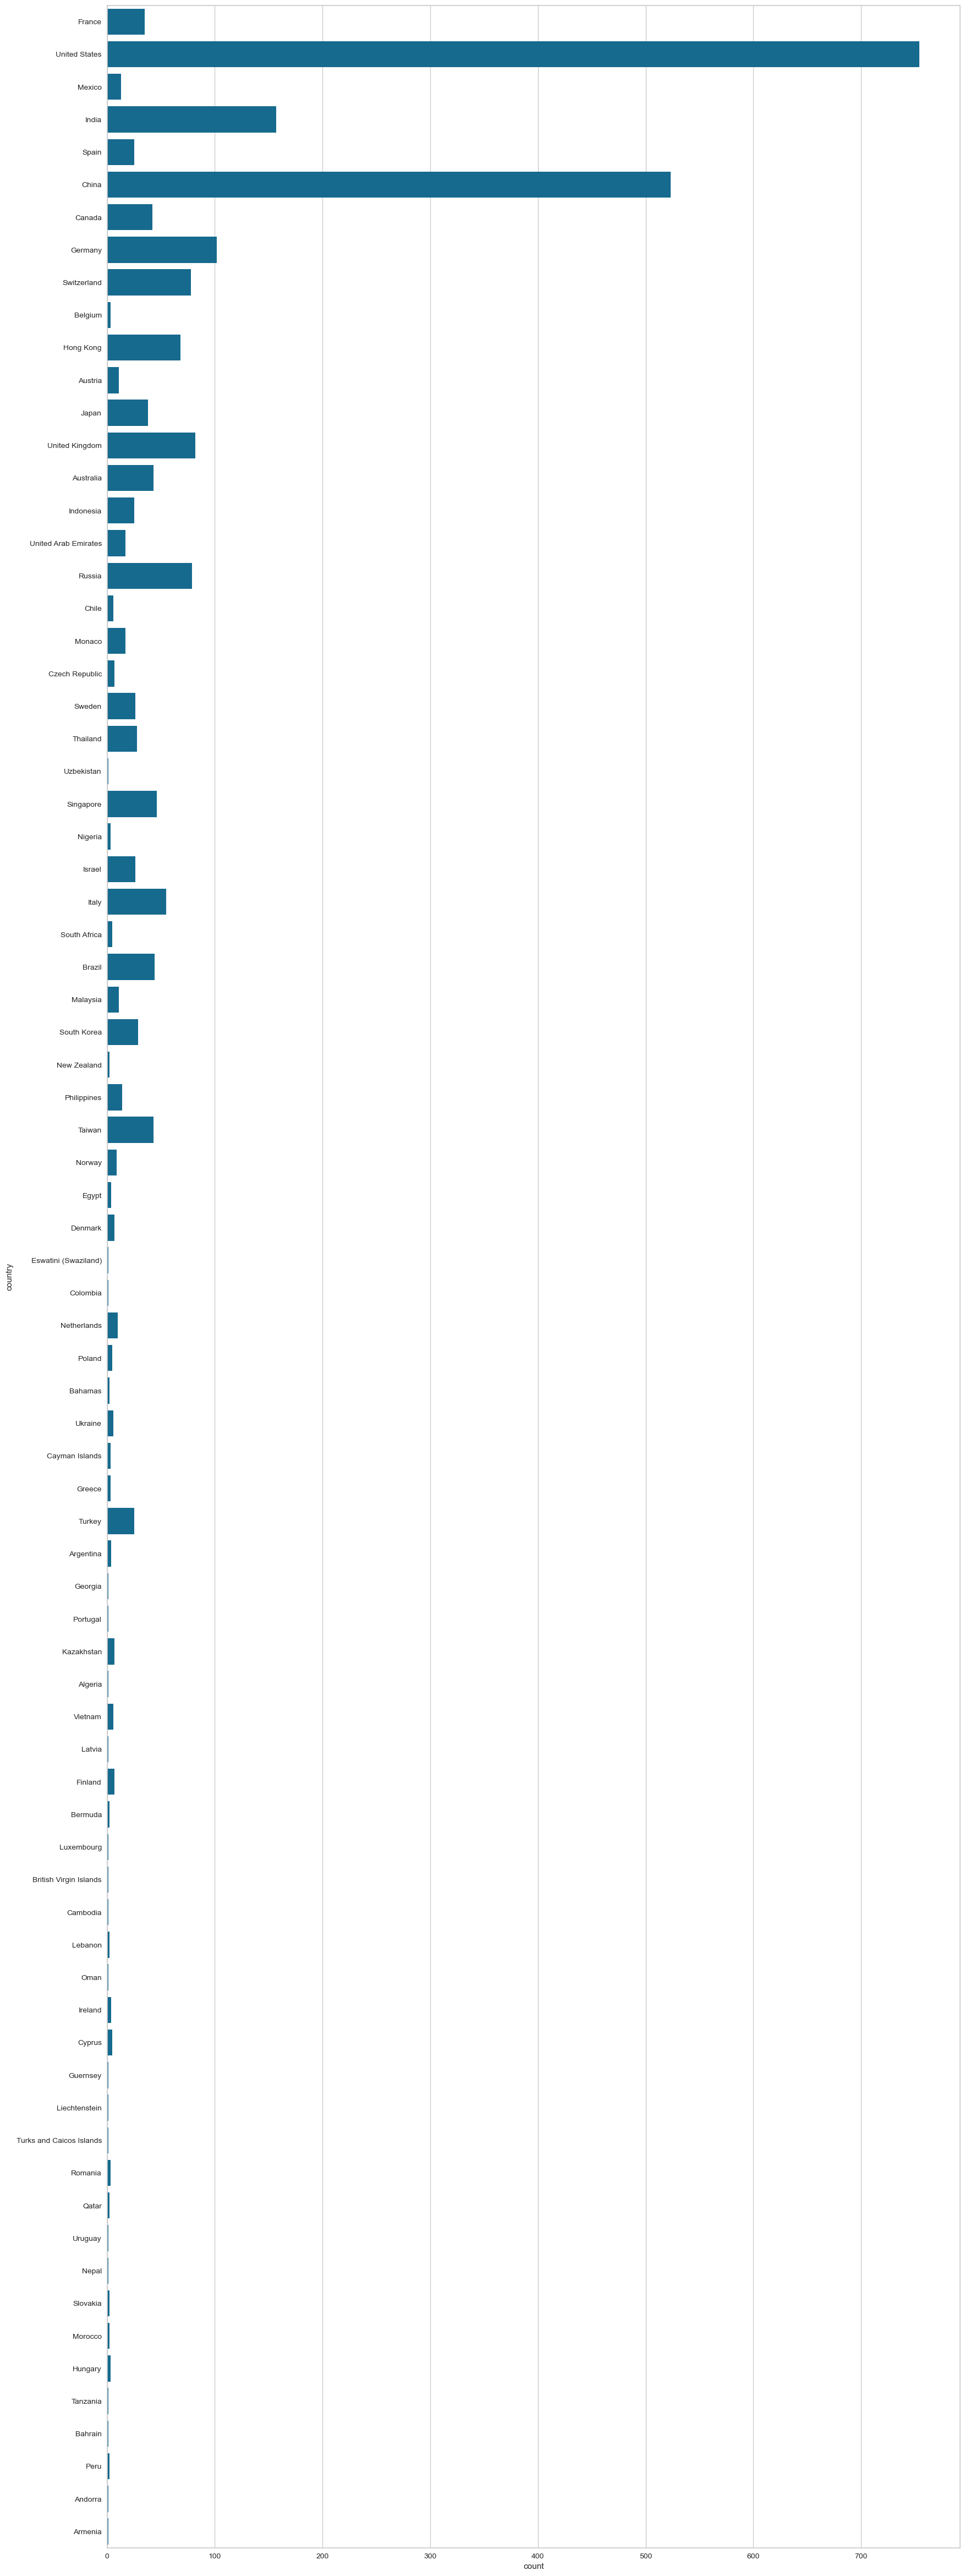

In [51]:
plt.figure(figsize=(20,60))
sns.countplot(y=df['country'])